# GES Employment Outcomes — Data Cleaning
**Dataset:** `ges_employment_outcomes.csv` (from CA2 Datasets, Brightspace)


This notebook only cleans `ges_employment_outcomes.csv`. The merge with `ges_degree_details` is previewed at the end, but the final merged dataset used for analysis should be built once in the group's main analysis notebook.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 60)

## 1. Load the dataset

Loading the raw file exactly as provided, with no assumptions about dtypes yet, so we can see the real state of the data first.

In [23]:
raw_path = "Data/ges_employment_outcomes.csv"  # rename to match your local copy if needed
df = pd.read_csv(raw_path)

print("Shape:", df.shape)
df.head()

Shape: (5135, 48)


,employment_rate_overall,employment_rate_ft_perm,basic_monthly_mean,basic_monthly_median,gross_monthly_mean,gross_monthly_median,gross_mthly_25_percentile,gross_mthly_75_percentile,gross_monthly_mean.1,gross_monthly_median.1,gross_mthly_25_percentile.1,gross_mthly_75_percentile.1,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Key
0,97.4,96.1,3701,3200,3727,3350,2900,4000,3727,3350,2900,4000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,97.1,95.7,2850,2700,2938,2700,2700,2900,2938,2700,2700,2900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
2,90.9,85.7,3053,3000,3214,3000,2700,3500,3214,3000,2700,3500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
3,87.5,87.5,3557,3400,3615,3400,3000,4100,3615,3400,3000,4100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
4,95.3,95.3,3494,3500,3536,3500,3100,3816,3536,3500,3100,3816,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5


## 2. Initial inspection

Checking structure, dtypes, and nulls before doing anything else.

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5135 entries, 0 to 5134
Data columns (total 48 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   employment_rate_overall      5027 non-null   object 
 1   employment_rate_ft_perm      5027 non-null   object 
 2   basic_monthly_mean           5027 non-null   object 
 3   basic_monthly_median         5027 non-null   object 
 4   gross_monthly_mean           5027 non-null   object 
 5   gross_monthly_median         5027 non-null   object 
 6   gross_mthly_25_percentile    5027 non-null   object 
 7   gross_mthly_75_percentile    5027 non-null   object 
 8   gross_monthly_mean.1         5027 non-null   object 
 9   gross_monthly_median.1       5027 non-null   object 
 10  gross_mthly_25_percentile.1  5027 non-null   object 
 11  gross_mthly_75_percentile.1  5027 non-null   object 
 12  Unnamed: 12                  0 non-null      float64
 13  Unnamed: 13       

In [25]:
# How many columns are entirely empty?
empty_cols = df.columns[df.isna().all()]
print(f"Fully empty columns: {len(empty_cols)}")
print(list(empty_cols))

Fully empty columns: 35
['Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46']


**Finding:** The raw CSV has 48 columns, but only 12 contain any data. The other columns (mostly `Unnamed: 12` through `Unnamed: 46`) are artifacts of trailing commas in the source file and are completely empty. These will be dropped in Step 4.

## 3. Remove embedded duplicate header row(s)

This dataset appears to have been assembled by stacking multiple yearly tables. Occasionally, a header row from one of the original tables got pulled in as a data row. We detect this by checking whether a row's value equals its own column name.

In [26]:
# A genuine data row should never contain the literal column name as its value.
# Flag any row where the first data column's value equals its own column header.
header_mask = df["employment_rate_overall"] == "employment_rate_overall"
print(f"Embedded header rows found: {header_mask.sum()}")
df[header_mask]

Embedded header rows found: 1


,employment_rate_overall,employment_rate_ft_perm,basic_monthly_mean,basic_monthly_median,gross_monthly_mean,gross_monthly_median,gross_mthly_25_percentile,gross_mthly_75_percentile,gross_monthly_mean.1,gross_monthly_median.1,gross_mthly_25_percentile.1,gross_mthly_75_percentile.1,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Key
1262,employment_rate_overall,employment_rate_ft_perm,basic_monthly_mean,basic_monthly_median,gross_monthly_mean,gross_monthly_median,gross_mthly_25_percentile,gross_mthly_75_percentile,gross_monthly_mean,gross_monthly_median,gross_mthly_25_percentile,gross_mthly_75_percentile,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1263


In [27]:
df = df[~header_mask].reset_index(drop=True)
print("Shape after removing embedded header row(s):", df.shape)

Shape after removing embedded header row(s): (5134, 48)


## 4. Drop empty and duplicate columns

- The `Unnamed: *` columns are completely empty (100% null) — dropped.
- `gross_monthly_mean.1`, `gross_monthly_median.1`, `gross_mthly_25_percentile.1`, and `gross_mthly_75_percentile.1` are exact duplicates of their non-`.1` counterparts (verified below) — dropped.

In [28]:
# Confirm the .1 columns are true duplicates before dropping them
dup_pairs = [
    ("gross_monthly_mean", "gross_monthly_mean.1"),
    ("gross_monthly_median", "gross_monthly_median.1"),
    ("gross_mthly_25_percentile", "gross_mthly_25_percentile.1"),
    ("gross_mthly_75_percentile", "gross_mthly_75_percentile.1"),
]

for a, b in dup_pairs:
    match_rate = (df[a].fillna("MISSING") == df[b].fillna("MISSING")).mean()
    print(f"{a} vs {b}: {match_rate:.2%} identical")

gross_monthly_mean vs gross_monthly_mean.1: 100.00% identical
gross_monthly_median vs gross_monthly_median.1: 100.00% identical
gross_mthly_25_percentile vs gross_mthly_25_percentile.1: 100.00% identical
gross_mthly_75_percentile vs gross_mthly_75_percentile.1: 100.00% identical


In [29]:
# Drop fully empty columns + confirmed duplicate columns
cols_to_drop = list(empty_cols) + [b for _, b in dup_pairs]
df = df.drop(columns=cols_to_drop)

print("Shape after dropping empty/duplicate columns:", df.shape)
df.head()

Shape after dropping empty/duplicate columns: (5134, 9)


,employment_rate_overall,employment_rate_ft_perm,basic_monthly_mean,basic_monthly_median,gross_monthly_mean,gross_monthly_median,gross_mthly_25_percentile,gross_mthly_75_percentile,Key
0,97.4,96.1,3701,3200,3727,3350,2900,4000,1
1,97.1,95.7,2850,2700,2938,2700,2700,2900,2
2,90.9,85.7,3053,3000,3214,3000,2700,3500,3
3,87.5,87.5,3557,3400,3615,3400,3000,4100,4
4,95.3,95.3,3494,3500,3536,3500,3100,3816,5


## 5. Standardise missing value markers

Missing values in this dataset are stored as the literal string `'na'` rather than a true null. This is why every numeric column was read in as text (`object`) dtype instead of numeric. We replace `'na'` with proper `NaN`.

In [30]:
outcome_cols = [
    "employment_rate_overall",
    "employment_rate_ft_perm",
    "basic_monthly_mean",
    "basic_monthly_median",
    "gross_monthly_mean",
    "gross_monthly_median",
    "gross_mthly_25_percentile",
    "gross_mthly_75_percentile",
]

df[outcome_cols] = df[outcome_cols].replace("na", np.nan)

## 6. Convert columns to correct numeric dtype

Now that `'na'` has been replaced with real `NaN`, these columns can be safely converted to numeric types.

In [31]:
for col in outcome_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[outcome_cols].dtypes

employment_rate_overall      float64
employment_rate_ft_perm      float64
basic_monthly_mean           float64
basic_monthly_median         float64
gross_monthly_mean           float64
gross_monthly_median         float64
gross_mthly_25_percentile    float64
gross_mthly_75_percentile    float64
dtype: object

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5134 entries, 0 to 5133
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   employment_rate_overall    4656 non-null   float64
 1   employment_rate_ft_perm    4656 non-null   float64
 2   basic_monthly_mean         4656 non-null   float64
 3   basic_monthly_median       4656 non-null   float64
 4   gross_monthly_mean         4656 non-null   float64
 5   gross_monthly_median       4656 non-null   float64
 6   gross_mthly_25_percentile  4656 non-null   float64
 7   gross_mthly_75_percentile  4656 non-null   float64
 8   Key                        5134 non-null   int64  
dtypes: float64(8), int64(1)
memory usage: 361.1 KB


## 7. Check for duplicate rows

`Key` should be unique (it's the join key to `ges_degree_details`), so we check both full-row duplicates and duplicate Keys.

In [33]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicate Key values:", df['Key'].duplicated().sum())

Fully duplicated rows: 0
Duplicate Key values: 0


## 8. Handle missing values

Each of the 8 outcome columns has the same number of missing values. This is expected: SkillsFuture/GES suppresses salary and employment rate figures for degree cohorts with very small graduating numbers (to protect individual privacy), rather than these being data entry errors.

**Decision:** We keep these rows with `NaN` rather than dropping them, for two reasons:
1. Dropping rows here would break the row-alignment with `ges_degree_details.csv` on `Key`, since that dataset has no missing rows to match against.
2. The missingness itself is informative (small/niche cohorts) — imputing a salary figure would misrepresent those cohorts. Rows with missing values can be filtered out later, at analysis time, only for the specific columns/visualisations that need complete data (e.g. `.dropna(subset=[...])` before a boxplot or KDE plot).

In [34]:
missing_summary = df[outcome_cols].isna().sum().to_frame("missing_count")
missing_summary["missing_pct"] = (missing_summary["missing_count"] / len(df) * 100).round(2)
missing_summary

,missing_count,missing_pct
employment_rate_overall,478,9.31
employment_rate_ft_perm,478,9.31
basic_monthly_mean,478,9.31
basic_monthly_median,478,9.31
gross_monthly_mean,478,9.31
gross_monthly_median,478,9.31
gross_mthly_25_percentile,478,9.31
gross_mthly_75_percentile,478,9.31


## 9. Outlier check (boxplot)

A quick boxplot of the salary columns to see the spread and flag any extreme outliers before this data gets used downstream. We don't remove outliers here — legitimately high or low salaries are real and relevant to the research question — but it's worth visualising and noting.

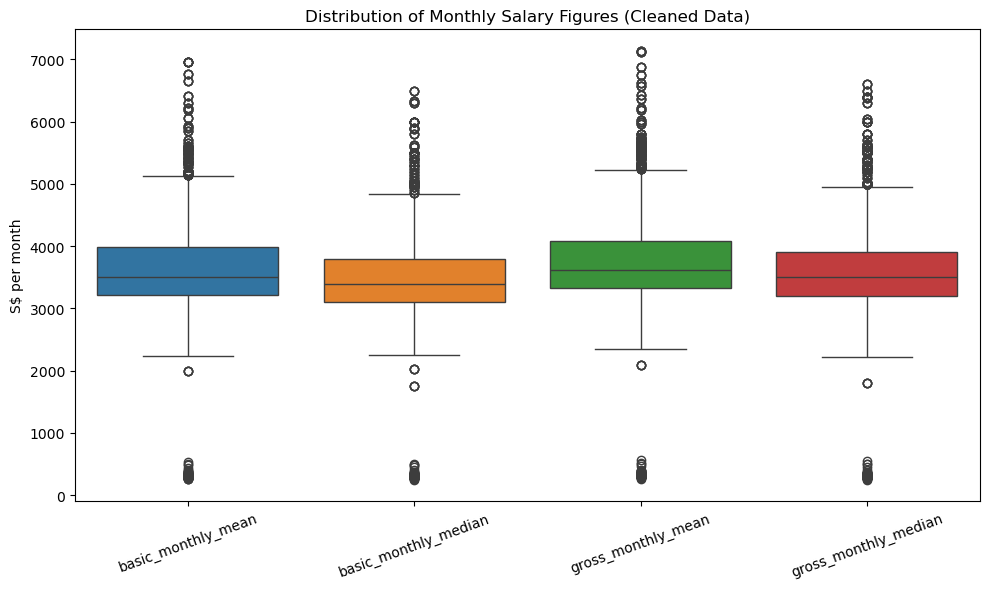

In [35]:
salary_cols = ["basic_monthly_mean", "basic_monthly_median", "gross_monthly_mean", "gross_monthly_median"]

plt.figure(figsize=(10, 6))
sns.boxplot(data=df[salary_cols].dropna())
plt.title("Distribution of Monthly Salary Figures (Cleaned Data)")
plt.ylabel("S$ per month")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 10. Final summary statistics

In [36]:
df[outcome_cols].describe()

,employment_rate_overall,employment_rate_ft_perm,basic_monthly_mean,basic_monthly_median,gross_monthly_mean,gross_monthly_median,gross_mthly_25_percentile,gross_mthly_75_percentile
count,4656.000000,4656.000000,4656.000000,4656.000000,4656.000000,4656.000000,4656.000000,4656.000000
mean,91.761662,81.954639,3617.053836,3492.168363,3732.680436,3584.053316,3254.724463,4041.400911
std,6.524101,14.536497,799.943893,747.767382,825.160580,780.663890,669.538439,961.207428
min,66.700000,14.300000,263.900000,250.000000,263.800000,250.000000,230.000000,290.000000
25%,88.000000,74.200000,3213.000000,3100.000000,3321.000000,3200.000000,3000.000000,3500.000000
50%,93.000000,85.500000,3504.000000,3400.000000,3616.000000,3500.000000,3200.000000,3900.000000
75%,97.000000,93.000000,3980.250000,3800.000000,4088.250000,3900.000000,3500.000000,4500.000000
max,100.000000,100.000000,6962.000000,6500.000000,7139.000000,6600.000000,6000.000000,9967.000000


## 11. Save cleaned dataset

Saving the cleaned dataset so it can be merged with `ges_degree_details.csv` (Ben's cleaned output) later, using `Key` as the join column.

In [37]:
df.to_csv("ges_employment_outcomes_cleaned.csv", index=False)
print("Saved: ges_employment_outcomes_cleaned.csv")
print("Final shape:", df.shape)

Saved: ges_employment_outcomes_cleaned.csv
Final shape: (5134, 9)


## 12. Preview merge with `ges_degree_details` (Ben's dataset)

This is just a preview to confirm the two cleaned datasets join correctly on `Key`. The group's main analysis notebook should perform the real merge once both cleaned CSVs are finalised.

In [38]:
degree_details_path = "Data/ges_degree_details.csv"  # Ben's cleaned file, once ready
degree_details = pd.read_csv(degree_details_path)

merged_preview = degree_details.merge(df, on="Key", how="inner")
print("Merged shape:", merged_preview.shape)
merged_preview.head()

Merged shape: (5134, 13)


,year,university,school,degree,Key,employment_rate_overall,employment_rate_ft_perm,basic_monthly_mean,basic_monthly_median,gross_monthly_mean,gross_monthly_median,gross_mthly_25_percentile,gross_mthly_75_percentile
0,2013,Nanyang Technological University,College of Business (Nanyang Business School),Accountancy and Business,1,97.4,96.1,3701.0,3200.0,3727.0,3350.0,2900.0,4000.0
1,2013,Nanyang Technological University,College of Business (Nanyang Business School),Accountancy (3-yr direct Honours Programme),2,97.1,95.7,2850.0,2700.0,2938.0,2700.0,2700.0,2900.0
2,2013,Nanyang Technological University,College of Business (Nanyang Business School),Business (3-yr direct Honours Programme),3,90.9,85.7,3053.0,3000.0,3214.0,3000.0,2700.0,3500.0
3,2013,Nanyang Technological University,College of Business (Nanyang Business School),Business and Computing,4,87.5,87.5,3557.0,3400.0,3615.0,3400.0,3000.0,4100.0
4,2013,Nanyang Technological University,College of Engineering,Aerospace Engineering,5,95.3,95.3,3494.0,3500.0,3536.0,3500.0,3100.0,3816.0


## Summary of cleaning steps performed

1. Loaded the raw CSV.
2. Detected and removed 1 embedded duplicate header row.
3. Dropped 35 fully empty `Unnamed` columns (artifacts of trailing commas in the source file).
4. Dropped 4 duplicate columns (`.1` suffix versions, verified identical to their originals).
5. Replaced the `'na'` string placeholder with proper `NaN` across all 8 outcome columns.
6. Converted all 8 outcome columns from text to numeric dtype.
7. Verified no duplicate rows and no duplicate `Key` values.
8. Documented and retained missing values (small-cohort data suppression) rather than dropping or imputing them.
9. Visualised salary distributions with a boxplot to check for outliers.
10. Saved the cleaned dataset as `ges_employment_outcomes_cleaned.csv`.
11. Verified the cleaned dataset merges correctly with `ges_degree_details` on `Key`.